In [1]:
import pandas as pd
import numpy as np
from scipy import sparse
from bioscan_dataset import CanadianInvertebrates
# pd.set_option('display.max_rows', 10)

# Creating Taxonomy

## Load the Data

In [2]:
dataset = CanadianInvertebrates(root="~/Datasets/bioscan/", target_type=["phylum", "class", "order", "family", "genus", "species"], split="all", download=False)
df = dataset.metadata
hierarchy = ["phylum", "class", "order", "family", "genus", "species"]
df = df[hierarchy + ["dna_barcode"]]

In [ ]:
# unique_letters = set("".join(df['dna_barcode']))

# # 2. Print the result sorted alphabetically
# print(f"Unique characters found: {sorted(unique_letters)}")

Unique characters found: ['A', 'C', 'G', 'N', 'T']


## Get Priors

In [11]:
# Get Priors

total_rows = len(df)
taxon_to_prior_map = {}

for rank in hierarchy:
    # Calculate frequency: (count of occurrences) / (total rows)
    # .dropna() ensures we only calculate priors for known names
    counts = df[rank].value_counts(dropna=False)
    priors = counts / total_rows
    
    taxon_to_prior_map[rank] = priors.to_dict()

unknown_prior_per_rank = {}
for rank in hierarchy:
    unknown_prior = taxon_to_prior_map[rank].get(np.nan, 0)
    unknown_prior_per_rank[rank] = unknown_prior

## Add NodeID and Level for each unique Taxonomic Path

In [13]:
df = df.drop(columns=['dna_barcode'])
df = df.drop_duplicates().reset_index(drop=True)

In [ ]:
current_id = 2
taxon_to_id_map = {}
df = df.sort_values(by=hierarchy)

for rank in hierarchy:
    unique_names = df[rank].dropna().unique()
    taxon_to_id_map[rank] = {name: i + current_id for i, name in enumerate(unique_names)}    
    current_id += len(unique_names)

print(f"\nTotal unique global IDs assigned: {current_id}")


Total unique global IDs assigned: 25613


In [ ]:
df['NodeID'] = -1
df['lvl'] = -1

for i, rank in enumerate(hierarchy):
    current_lvl = i + 2

    mapping = taxon_to_id_map.get(rank, {})
    current_rank_ids = df[rank].map(mapping)
    mask = current_rank_ids.notna()
    df.loc[mask, 'NodeID'] = current_rank_ids[mask]
    df.loc[mask, 'lvl'] = current_lvl

df['NodeID'] = df['NodeID'].astype(int)
df['lvl'] = df['lvl'].astype(int)

df

,phylum,class,order,family,genus,species,NodeID,lvl
3470,Annelida,Clitellata,Arhynchobdellida,Erpobdellidae,Erpobdella,Erpobdella punctata,8149,7
7237,Annelida,Clitellata,Arhynchobdellida,Erpobdellidae,Erpobdella,Erpobdella obscura,8150,7
15910,Annelida,Clitellata,Arhynchobdellida,Erpobdellidae,Erpobdella,Erpobdella microstoma,8151,7
10841,Annelida,Clitellata,Arhynchobdellida,Erpobdellidae,Erpobdella,NaN,1437,6
1198,Annelida,Clitellata,Arhynchobdellida,Erpobdellidae,Motobdella,Motobdella montezuma,8152,7
...,...,...,...,...,...,...,...,...
16250,Bryozoa,Phylactolaemata,Plumatellida,Fredericellidae,NaN,NaN,1433,5
17891,Bryozoa,Gymnolaemata,Cheilostomatida,Bugulidae,Caulibugula,Caulibugula ciliata,25611,7
16046,Bryozoa,NaN,NaN,NaN,NaN,NaN,13,2
16399,Priapulida,Priapulimorpha,Priapulimorphida,Priapulidae,Halicryptus,Halicryptus spinulosus,25612,7


## Add ParentID for each Node

In [21]:
df['ParentID'] = 1

hierarchy_reversed = hierarchy[::-1]

for rank in hierarchy_reversed[:-1]:  # Skip the last one (Phylum)
    # Get the mapping for the current rank
    mapping = taxon_to_id_map.get(rank, {})
    current_rank_ids = df[rank].map(mapping)
    
    # MASK: Rows where the current global_node_id IS this rank
    is_current_rank_mask = (df['NodeID'] == current_rank_ids)
    
    # Identify the parent rank (the one immediately above it in the hierarchy)
    current_rank_idx = hierarchy.index(rank)
    parent_rank = hierarchy[current_rank_idx - 1]
    
    # Get the parent IDs for that rank
    parent_mapping = taxon_to_id_map.get(parent_rank, {})
    parent_ids = df[parent_rank].map(parent_mapping)

    df.loc[is_current_rank_mask, 'ParentID'] = parent_ids[is_current_rank_mask]

# Ensure integer type
df['ParentID'] = df['ParentID'].astype(int)
df = df.sort_values(by=['ParentID', 'NodeID']).reset_index(drop=True)

df

,phylum,class,order,family,genus,species,NodeID,lvl,ParentID
0,Arthropoda,NaN,NaN,NaN,NaN,NaN,2,2,1
1,Mollusca,NaN,NaN,NaN,NaN,NaN,6,2,1
2,Nemertea,NaN,NaN,NaN,NaN,NaN,8,2,1
3,Platyhelminthes,NaN,NaN,NaN,NaN,NaN,12,2,1
4,Bryozoa,NaN,NaN,NaN,NaN,NaN,13,2,1
...,...,...,...,...,...,...,...,...,...
20749,Porifera,Demospongiae,Haplosclerida,Chalinidae,Haliclona,Haliclona xena,25608,7,8144
20750,Porifera,Demospongiae,Chondrillida,Halisarcidae,Halisarca,Halisarca dujardini,25609,7,8145
20751,Bryozoa,Stenolaemata,Cyclostomatida,Heteroporidae,Heteropora,Heteropora pacifica,25610,7,8146
20752,Bryozoa,Gymnolaemata,Cheilostomatida,Bugulidae,Caulibugula,Caulibugula ciliata,25611,7,8147


## Convert to Taxonomy

In [8]:
def build_taxonomy_dataframe(df, taxon_to_id_map, taxon_to_prior_map, hierarchy):
    tree_rows = []
    tree_rows.append({'nid': 0, 'pid': 0, 'lvl': 0, 'name': 'root', 'prior': 1.0})        # To add the root.
    tree_rows.append({'nid': 1, 'pid': 0, 'lvl': 1, 'name': 'kingdom','prior': 1.0})        # To add the kingdom.

    for i, rank in enumerate(hierarchy):
        current_level = i + 2
        
        if i == 0:      # Means we are at the Phylum level, which is the top of the hierarchy
            unique_phyla = df[rank].dropna().unique()
            for name in sorted(unique_phyla):
                node_id = taxon_to_id_map[rank][name]
                prior = taxon_to_prior_map[rank][name]
                tree_rows.append({
                    'nid': int(node_id),
                    'pid': 1,                 # Choose the parent ID for Phylum (should be the root)
                    'lvl': current_level,
                    'name': name,
                    'prior': prior
                })
        else:
            # For subsequent ranks, the parent comes from the rank immediately above it
            parent_rank = hierarchy[i-1]
            
            # Identify unique Parent-Child name pairs
            unique_pairs = df[[parent_rank, rank]].dropna().drop_duplicates()
            
            # Sort by child name to keep the listing organized
            for _, row in unique_pairs.sort_values(by=rank).iterrows():
                parent_name = row[parent_rank]
                child_name = row[rank]
                
                # Map names to their Global Node IDs
                node_id = taxon_to_id_map[rank][child_name]
                parent_id = taxon_to_id_map[parent_rank][parent_name]
                prior = taxon_to_prior_map[rank][child_name]
                
                tree_rows.append({
                    'nid': int(node_id),
                    'pid': int(parent_id),
                    'lvl': current_level,
                    'name': child_name,
                    'prior': prior
                })
    
    # 3. Create the final DataFrame
    return pd.DataFrame(tree_rows).sort_values(by=['pid', 'nid']).reset_index(drop=True)

In [9]:
taxonomy_df = build_taxonomy_dataframe(df, taxon_to_id_map, taxon_to_prior_map, hierarchy)
taxonomy_df_test = taxonomy_df.copy()

## Test from the python file

In [10]:
from bioscan_convert import *

In [ ]:
full_df, hierarchy = load_dataset(split="all")
TAXAXAX = convert_to_taxonomy(full_df, hierarchy)

## Test edits live

In [15]:
def get_descendants(nodes, N, layers):
    """
    Get the path to the root for each node.
    """

    # TODO fix this
    res = (np.ones((nodes.shape[0], 8))*N).astype(int)      # Initialize the result array with N to be treated as out of bounds when classified.
    for n in range(1, nodes.shape[0]):
        
        curr_nid = nodes[n]  # parent of node n
        res[n][layers[curr_nid]] = curr_nid # add parent to it's layer in the path.

        # while curr isn't root, walk up the tree and add parents to the path.
        while curr_nid != 0:    # assumes root is 0
            curr_nid = nodes[curr_nid]  # parent of parent
            res[n][layers[curr_nid]] = curr_nid
            
        res[n][layers[n]] = n # add self to the path.
    
    res[0][0] = 0 # root's path is just itself.
    return res

def create_final_mapping(taxon_to_id_map, sequential_mapping):
    final_mapping = {}

    for _, name_to_id_dict in taxon_to_id_map.items():
        for name, original_nid in name_to_id_dict.items():
            final_mapped_id = sequential_mapping.get(original_nid)
            final_mapping[name] = final_mapped_id
                
    return final_mapping

In [16]:
taxonomy_df_test.set_index("nid", inplace=True)  

nid = taxonomy_df_test.index.max() + 1
parents = taxonomy_df_test["pid"].unique() 
parents = parents[2:]

parent_levels = taxonomy_df_test.loc[parents, "lvl"]

lvl_to_rank = {i + 2: rank for i, rank in enumerate(hierarchy)}

unk_priors = [
    unknown_prior_per_rank.get(lvl_to_rank.get(lvl + 1), 0) 
    for lvl in parent_levels
]

unk_df = pd.DataFrame({
    "nid": range(nid, nid + len(parents)),
    "pid": parents,
    "lvl": parent_levels + 1,
    "name": "unk",
    "prior": unk_priors 
}).set_index("nid")


taxonomy_df_test = pd.concat([taxonomy_df_test, unk_df])

In [17]:
taxonomy_df_test = taxonomy_df_test.reset_index()
taxonomy_df_test = taxonomy_df_test.set_index("pid").sort_index() # set parentid as index and sort by it
second_mapping = dict(zip(taxonomy_df_test["nid"], range(len(taxonomy_df_test["nid"]))))
taxonomy_df_test["nid"] = taxonomy_df_test["nid"].map(second_mapping)
taxonomy_df_test.index = taxonomy_df_test.index.map(second_mapping)

In [18]:
segments = taxonomy_df_test.index.to_numpy()
segments[0] = -1
prior = taxonomy_df_test["prior"].to_numpy()
ranks = taxonomy_df_test["lvl"].to_numpy()
unk = (taxonomy_df_test["name"] == "unk").to_numpy()
unk = np.expand_dims(unk, axis=1)
paths = get_descendants(segments, len(df), ranks)
final_mapping = create_final_mapping(taxon_to_id_map, second_mapping)

# Converting Training Data

In [2]:
def load_dataset(split):
    dataset = CanadianInvertebrates(root="~/Datasets/bioscan/", target_type=["phylum", "class", "order", "family", "genus", "species"], split=split, download=False)
    df = dataset.metadata
    hierarchy = ["phylum", "class", "order", "family", "genus", "species"]
    df = df[hierarchy + ["dna_barcode"]]
    return df, hierarchy

def get_seq_bits(seq_str):
    """
    Convert seqence string to bit representation
    """
    seq_chars = np.frombuffer(seq_str.encode('ascii'), np.int8)
    a = seq_chars == 65
    t = seq_chars == 84
    g = seq_chars == 71
    c = seq_chars == 67
    ok = np.logical_or.reduce([a, t, g, c])

    seq_bits = np.array([a, t, g, c, ok])
    return seq_bits

def pack_seqs(dna_barcodes):

    ref_list = []
    ok_pos = []
    max_len = dna_barcodes.str.len().max()

    for seq in dna_barcodes:
        padded_seq = seq.ljust(max_len, 'N')
        seq_bits = get_seq_bits(padded_seq)
        ref_list.append(np.packbits(seq_bits[:4], axis=None))
        ok_pos.append(np.packbits(seq_bits[4], axis=None))

    return np.array(ref_list), np.array(ok_pos)

def lil_to_csr(lil, shape):
    """
    Converts a list of lists to a csr matrix
    lil: list of lists where each list contains the column indices of the non-zero elements in the row
    shape: (n_rows, n_cols)
    """

    num_nonzero = 0
    indices = []
    indptr = [0]

    for row in lil:
        num_nonzero += len(row)
        indptr.append(num_nonzero)
        indices.extend(row)
    
    data = np.ones(num_nonzero, dtype=bool)
    csr = sparse.csr_matrix((data, indices, indptr), shape=shape, dtype=bool)
    return csr

In [23]:
train_df, _ = load_dataset(split="train")
train_df.reset_index(drop=True, inplace=True)

In [24]:
taxonomy_length = len(taxonomy_df_test)
name2id = final_mapping

no_refs = np.ones((taxonomy_length, 1), dtype=bool)
has_refs = set()

node2seq = [[] for _ in range(taxonomy_length)]

In [25]:
name2id = final_mapping

taxonomy_length = len(taxonomy_df_test)
sequences_length = len(train_df)

no_refs = np.ones((taxonomy_length, 1), dtype=bool)   # To track which nodes have no references
has_refs = set()                        # To track which nodes have references
node2seq = [[] for _ in range(taxonomy_length)]

for idx, taxon in train_df.iterrows():
    curr_nids = [0,1]   # Add root and kingdom

    for rank in hierarchy:
        if taxon[rank] is not np.nan:
            curr_nids.append(name2id[taxon[rank]])

    for nid in curr_nids:
        has_refs.add(nid)
        node2seq[nid].append(idx)

In [26]:
# mask out nodes that have references.
no_refs[list(has_refs)] = False
node_state = no_refs*np.logical_not(unk)    # marks nodes that are known but Empty
node_state = np.concatenate([node_state, np.logical_not(no_refs)], axis=1)  # concatenate to [N, 2], [known_empty, has_refs]

In [27]:
node2seq = lil_to_csr(node2seq, (taxonomy_length, sequences_length))
n2s_indices = node2seq.indices
n2s_indptr = node2seq.indptr

In [28]:
refs, ok_pos = pack_seqs(train_df["dna_barcode"])

In [ ]:
# assign_sequences_to_taxonomy("CanadianInvertebrates_taxonomy_temp.npz", train_df, hierarchy)

## Comparison

In [59]:
npz_file = np.load("../models/ref_db/canadian_invertebrates/CanadianInvertebrates_taxonomy_temp.npz", allow_pickle=True)
npz_file2 = np.load("CanadianInvertebrates_taxonomy_temp.npz", allow_pickle=True)

In [58]:
a = npz_file["segments"]
b = segments

np.array_equal(a, b)

False

In [60]:
dict_1 = npz_file["name_to_id_map"].item()
dict_2 = npz_file2["name_to_id_map"].item()

In [61]:
print(dict_1 == dict_2)

False


In [62]:
common = set(dict_1) & set(dict_2)
diffs = {k: (dict_1[k], dict_2[k]) for k in common if dict_1[k] != dict_2[k]}

In [64]:
i = 0
for k in diffs.keys():
    i += 1

print(i)

20996


# Experiments

In [3]:
def read_mapping(taxonomy_dir: str):
    taxonomy = np.load(taxonomy_dir, allow_pickle=True)
    name_to_id_map = taxonomy["name_to_id_map"].item()
    taxonomy.close()
    return name_to_id_map

def load_dataset(split):
    dataset = CanadianInvertebrates(root="~/Datasets/bioscan/", target_type=["phylum", "class", "order", "family", "genus", "species"], split=split, download=False)
    df = dataset.metadata
    hierarchy = ["phylum", "class", "order", "family", "genus", "species"]
    df = df[hierarchy + ["dna_barcode"]]
    return df, hierarchy

## list_of_labels.txt

In [ ]:
train_df, hierarchy = load_dataset(split="train")
name_to_id_map = read_mapping("../datasets/canadian_invertebrates/full_tax/taxonomy.npz")

In [ ]:
# len(train_df)
# train_df["species"].nunique()

1653

In [7]:
labels = []
for label in train_df["species"]:
    labels.append(name_to_id_map[label])

In [98]:
with open('list_of_labels_nodeIDs.txt', 'w') as f:
    for item in labels:
        f.write(f"{item}\n")

## train-targets

In [8]:
def create_targets_fast(df, hierarchy, name_to_id_map):

    results = []
    for _, row in df.iterrows():
        row_ids = [-1] * 7
        row_ids[0] = 1
        for i, rank in enumerate(hierarchy):
            row_ids[i+1] = name_to_id_map.get(row[rank], -1)

        results.append(row_ids)

    return results

In [9]:
train_df.reset_index(drop=True, inplace=True)
train_df

,phylum,class,order,family,genus,species,dna_barcode
0,Arthropoda,Insecta,Orthoptera,Acrididae,Melanoplus,Melanoplus infantilis,TACCTTATATTTTATATTTGGAGCATGAGCTGGAATAGTAGGAACT...
1,Arthropoda,Insecta,Orthoptera,Acrididae,Melanoplus,Melanoplus infantilis,TACCTTATATTTTATATTTGGAGCATGAGCTGGAATAGTAGGAACT...
2,Arthropoda,Insecta,Orthoptera,Acrididae,Melanoplus,Melanoplus infantilis,TACCTTATATTTTATATTTGGAGCATGAGCTGGAATAGTAGGAACT...
3,Arthropoda,Insecta,Orthoptera,Acrididae,Melanoplus,Melanoplus infantilis,TACCTTATATTTTATATTTGGAGCATGAGCTGGAATAGTAGGAACT...
4,Arthropoda,Insecta,Orthoptera,Acrididae,Melanoplus,Melanoplus infantilis,TACCTTATATTTTATATTTGGAGCATGAGCTGGAATAGTAGGAACT...
...,...,...,...,...,...,...,...
47081,Arthropoda,Insecta,Lepidoptera,Yponomeutidae,Paraswammerdamia,Paraswammerdamia lapponica,TTTATTTTTGGAATTTGATCAGGAATAGTAGGAACCTCTTTAAGAT...
47082,Arthropoda,Insecta,Lepidoptera,Yponomeutidae,Paraswammerdamia,Paraswammerdamia lapponica,NNNNNNNNNNTTTATTTTTGGAATTTGATCAGGAATAGTAGGAACC...
47083,Arthropoda,Insecta,Lepidoptera,Yponomeutidae,Paraswammerdamia,Paraswammerdamia conspersella,AACATTATATTTTATTTTTGGAATTTGATCAGGAATAGTAGGAACT...
47084,Arthropoda,Insecta,Lepidoptera,Yponomeutidae,Paraswammerdamia,Paraswammerdamia conspersella,GGAATAGTAGGAACTTCTTTAAGATTATTAATTCGTGCTGAATTGG...


In [ ]:
list_of_targets = create_targets_fast(train_df, hierarchy, name_to_id_map)
targets_df = pd.DataFrame(list_of_targets)
targets_df_tr = targets_df.T
targets_df_tr.to_csv('train-targets.csv', index=True)

,0,1,2,3,4,5,6
0,1,13,32,141,1184,8351,30707
1,1,13,32,141,1184,8351,30707
2,1,13,32,141,1184,8351,30707
3,1,13,32,141,1184,8351,30707
4,1,13,32,141,1184,8351,30707
...,...,...,...,...,...,...,...
47081,1,13,32,159,1126,8208,30362
47082,1,13,32,159,1126,8208,30362
47083,1,13,32,159,1126,8208,30361
47084,1,13,32,159,1126,8208,30361


## Convert to .aln

In [7]:
def save_df_to_protax_format(df, hierarchy):
    # The ranks you want to include in the header
    hierarchy = ['phylum', 'class', 'order', 'family', 'genus', 'species']
    
    with open("refs.aln", 'w', encoding='latin-1') as f:
        for _, row in df.iterrows():
            taxonomy_str = ",".join([str(row[rank]) for rank in hierarchy if pd.notna(row[rank])])            
            header = f"{taxonomy_str}\t\n"            
            sequence = str(row['dna_barcode']).strip()
            
            f.write(header)
            f.write(f"{sequence}\n")

save_df_to_protax_format(train_df, hierarchy)

## Tiny Taxonomy

In [8]:
train_df, hierarchy = load_dataset(split="train")
train_df.reset_index(drop=True, inplace=True)

In [9]:
selected_genera = ["Fannia", "Paratanytarsus"]
filtered_df = train_df[train_df['genus'].isin(selected_genera)]

selected_species = filtered_df['species'].drop_duplicates().sample(n=5, random_state=42).tolist()
filtered_df = filtered_df[filtered_df['species'].isin(selected_species)]

In [10]:
filtered_df

,phylum,class,order,family,genus,species,dna_barcode
9336,Arthropoda,Insecta,Diptera,Chironomidae,Paratanytarsus,Paratanytarsus natvigi,GGAATAATCGGAACATCATTAAGAATGCTAATTCGAGCAGAATTAN...
9340,Arthropoda,Insecta,Diptera,Chironomidae,Paratanytarsus,Paratanytarsus natvigi,TCTTTATATTTTATTTTCGGAGCTTGATCAGGAATAATCGGAACAT...
9347,Arthropoda,Insecta,Diptera,Chironomidae,Paratanytarsus,Paratanytarsus natvigi,GTTCTTTATATTTTATTTTCGGGGCTTGATCAGGAATAATCGGAAC...
9352,Arthropoda,Insecta,Diptera,Chironomidae,Paratanytarsus,Paratanytarsus sp. TE04,TTCTTTATATTTCATTTTTGGAGCATGATCAGGAATAGTTGGTACT...
9359,Arthropoda,Insecta,Diptera,Chironomidae,Paratanytarsus,Paratanytarsus sp. TE04,TGATCAGGAATAGTTGGTACTTCTTTAAGAATATTAATTCGAGCCG...
...,...,...,...,...,...,...,...
18915,Arthropoda,Insecta,Diptera,Fanniidae,Fannia,Fannia atra,AACATTATATTTTATTTTTGGTGCTTGATCTGGTATAATCGGAACA...
18925,Arthropoda,Insecta,Diptera,Fanniidae,Fannia,Fannia nr. ungulata,ACATTATATTTTATCCTTGGTGCTTGATCTGGAATAATTGGAACAT...
18928,Arthropoda,Insecta,Diptera,Fanniidae,Fannia,Fannia corvina,GGTATAATTGGTACTTCTTTAAGTATTCTAATTCGAGCTGAATTAG...
18937,Arthropoda,Insecta,Diptera,Fanniidae,Fannia,Fannia nr. ungulata,ACATTATATTTTATCCTTGGTGCTTGATCTGGAATAATTGGAACAT...


In [37]:
sequences = [filtered_df.iloc[0]["dna_barcode"]]
filtered_df.iloc[100]

phylum                                                Arthropoda
class                                                    Insecta
order                                                    Diptera
family                                                 Fanniidae
genus                                                     Fannia
species                                           Fannia corvina
dna_barcode    ACTTTATATTTTATTTTTGGAGCTTGATCAGGTATAATTGGTACTT...
Name: 18748, dtype: object

In [12]:
tiny_tree = filtered_df.copy().drop(columns=["dna_barcode"])
tiny_tree.drop_duplicates(inplace=True)
tiny_tree

,phylum,class,order,family,genus,species
9336,Arthropoda,Insecta,Diptera,Chironomidae,Paratanytarsus,Paratanytarsus natvigi
9352,Arthropoda,Insecta,Diptera,Chironomidae,Paratanytarsus,Paratanytarsus sp. TE04
18550,Arthropoda,Insecta,Diptera,Fanniidae,Fannia,Fannia corvina
18555,Arthropoda,Insecta,Diptera,Fanniidae,Fannia,Fannia atra
18558,Arthropoda,Insecta,Diptera,Fanniidae,Fannia,Fannia nr. ungulata


In [8]:
taxonomy = np.load('../datasets/canadian_invertebrates/full_tax/taxonomy.npz', allow_pickle=True)
print("Arrays in this file:", taxonomy.files)

Arrays in this file: ['segments', 'parents', 'unk', 'ranks', 'prior', 'paths', 'names', 'name_to_id_map', 'refs', 'ok_pos', 'n2s_indices', 'n2s_indptr', 'node_state']


In [9]:
taxa = taxonomy["names"]
parents = taxonomy["parents"]
segments = taxonomy["segments"]
ranks = taxonomy["ranks"]
paths = taxonomy["paths"]
name_to_id_map = taxonomy["name_to_id_map"].item()

In [18]:
parents[:10]

array([-1,  0,  1,  1,  1,  1,  1,  1,  1,  1], dtype=int32)

In [74]:
current_children = np.where(parents == 2)[0]
current_children

array([3, 4])

In [72]:
segments

array([0, 1, 2, 3, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 8, 8, 9, 9, 9, 9])

In [39]:
def get_children(node, parents):
    children = []
    for i in range(len(parents)):
        if parents[i] == node:
            children.append(i)
    return children

In [50]:
get_children(15, parents)

[]

### Tree

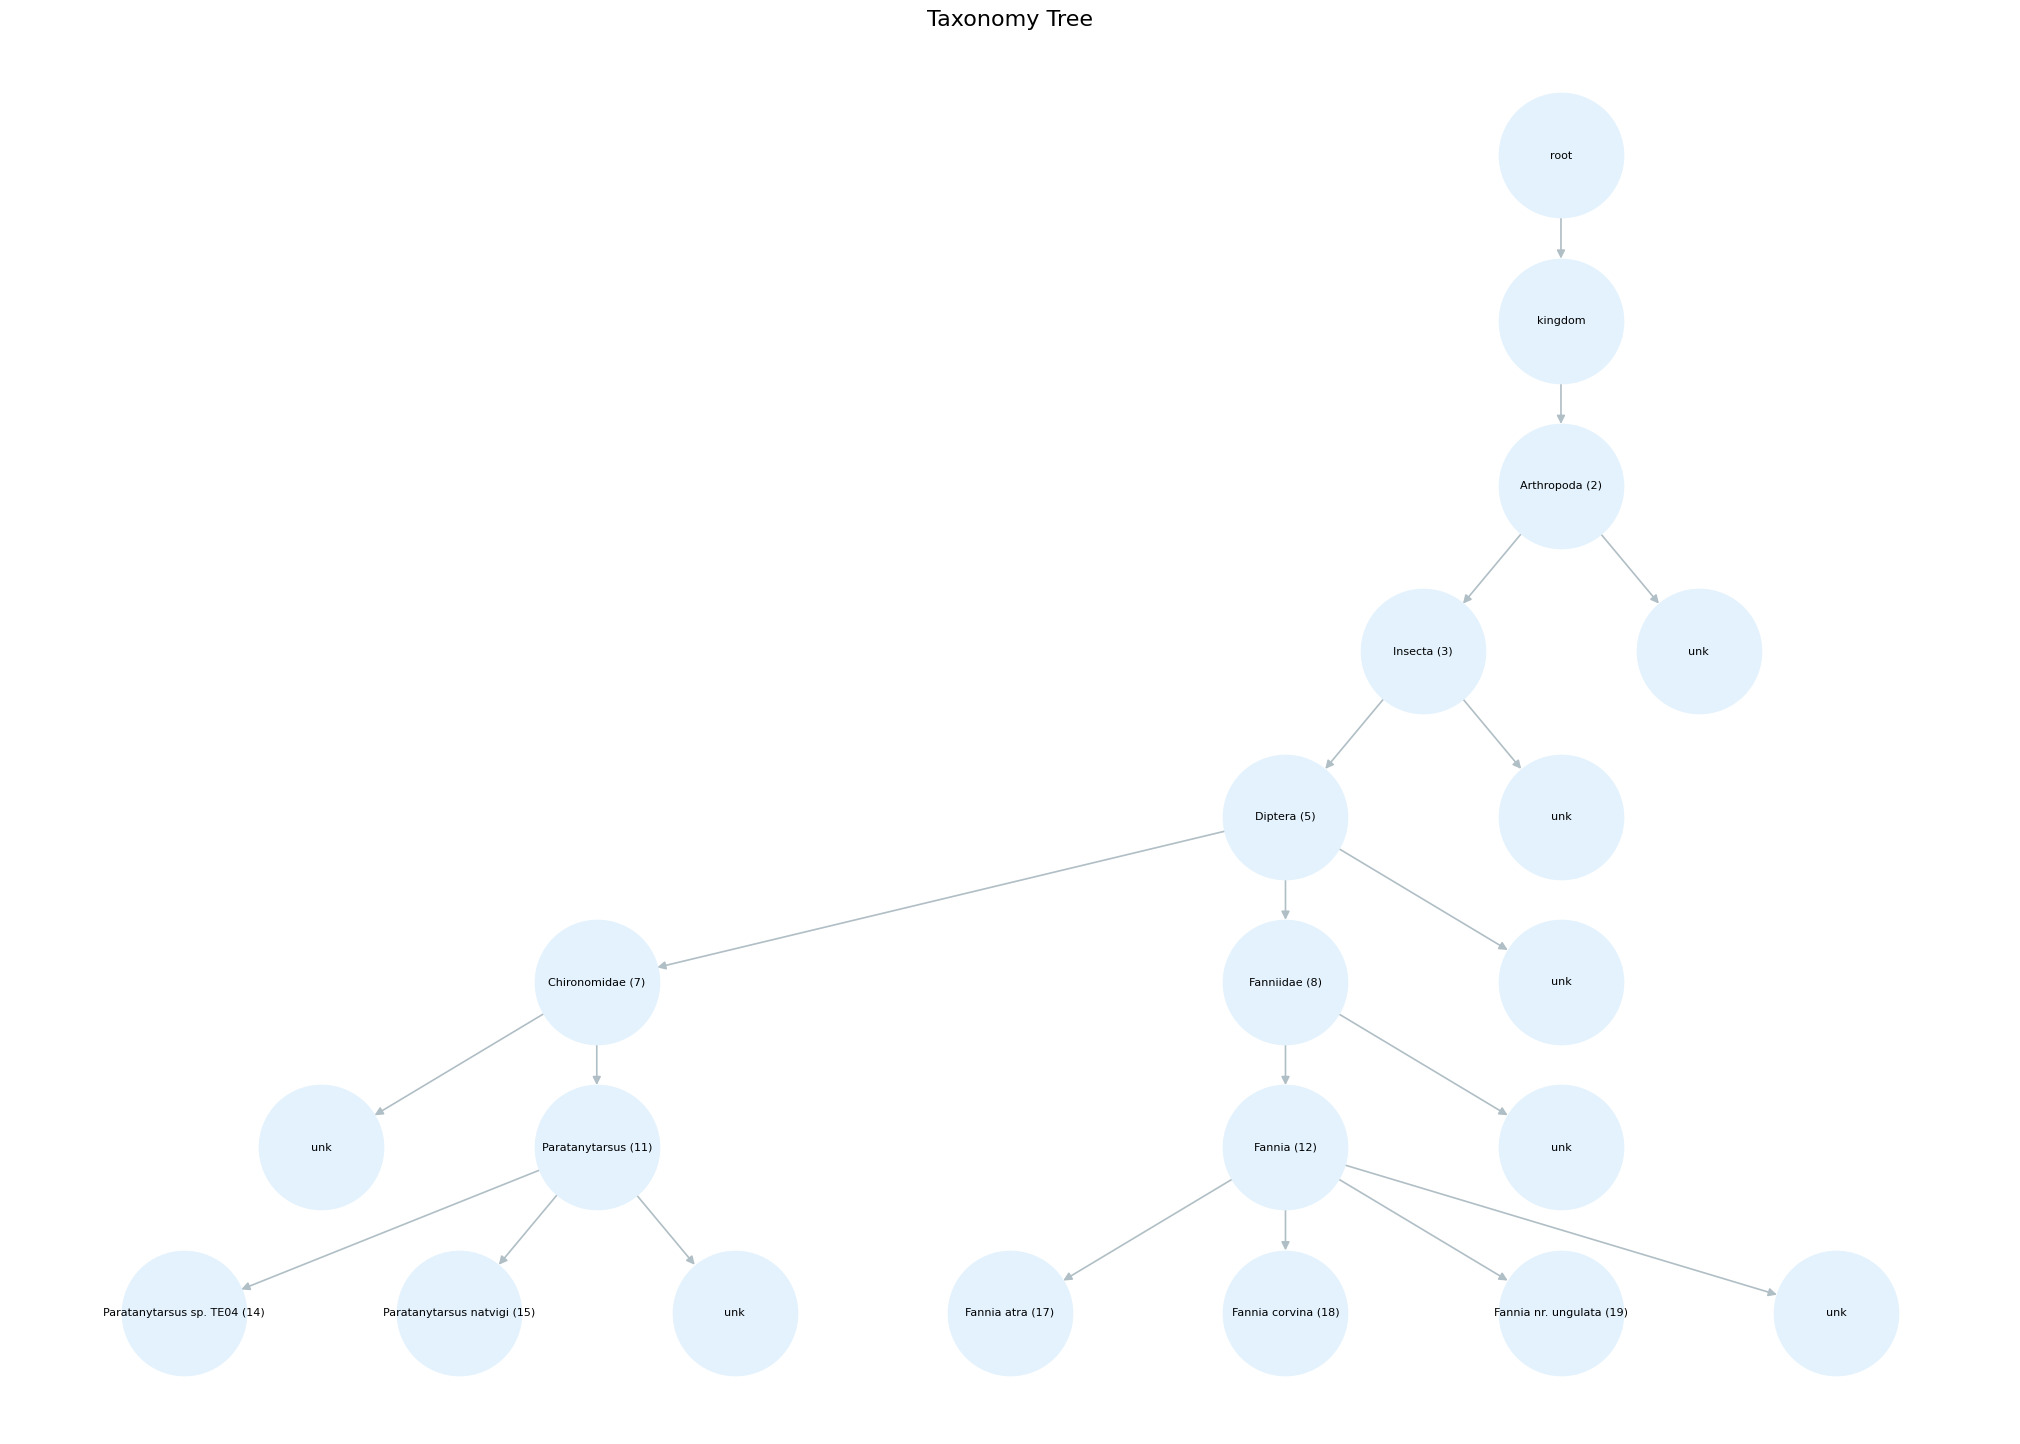

In [26]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout


# Build Graph
G = nx.DiGraph()
labels = {}

for i, name in enumerate(taxa):

    # Append id if name exists in dictionary
    if name in name_to_id_map:
        label = f"{name} ({name_to_id_map[name]})"
    else:
        label = name

    labels[i] = label
    G.add_node(i)

# Add edges
for child, parent in enumerate(parents):
    if parent != -1:
        G.add_edge(parent, child)

# Graphviz hierarchical layout
pos = graphviz_layout(G, prog="dot")

# Compress vertical spacing to shorten arrows
pos = {k: (x, y * 0.3) for k, (x, y) in pos.items()}

# Plot
plt.figure(figsize=(20, 14))

nx.draw(
    G,
    pos,
    labels=labels,
    with_labels=True,
    node_size=8000,
    node_color="#e3f2fd",
    edge_color="#b0bec5",
    font_size=8,
    arrows=True,
    arrowsize=12,
    width=1.2
)

plt.title("Taxonomy Tree", fontsize=16)
plt.show()

## Overlap check

In [ ]:
test_df, _ = load_dataset(split="test")
train_df, _ = load_dataset(split="train")

47086

In [9]:
test_species = test_df["species"].unique().tolist()
train_species = train_df["species"].unique().tolist()

print(len(test_species))
print(len(train_species))

is_subset = set(test_species).issubset(set(train_species))

print(is_subset)  # Output: True

1653
1653
True


# Appendix